In [2]:
import numpy as np
import jax
import jaxlib
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
import os
import glob

#os.chdir("/home/ihuarte/Escritorio/Ivan/NN/")

# from ATMOS_VA.VA_project.src.VA_project.model.model import OxalateJKGamma
# from ATMOS_VA.VA_project.src.VA_project.engine.runners import Runner

#from NN_utils import load_vstate
#from correlations import correlations_vstate

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
jax.devices()

[CpuDevice(id=0)]

In [4]:
a= np.zeros((1,2,0,3))
a

array([], shape=(1, 2, 0, 3), dtype=float64)

In [ ]:
%run ./SplitTraining_simulation_LRM.py


Total samples: 1024


────────────────────────── 🔧 CM: LRSquare   🧠 NN_architecture: SplitTraining_CvT3_CvT3 ──────────────────────────

🧱 Size: 4x5

╭─────────────────────────────────────────────────── LRSquare ────────────────────────────────────────────────────╮
│ fields= [-1.0, 0.0]  ops= [['Y', 'Z'], ['ZZ']]  J= 0.0  alpha= 2.5                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── SplitTraining_CvT3_CvT3 ────────────────────────────────────────────╮
│ n_CP_blocks_1= [2]     CTemb_channels_1=     CP_channels_1= [32]   attn_heads_1= [4]      kernel_1= [3, 3]      │
│                        [32]                                                                                     │
│ final_architecture_1=  symm_Z2_1= True       trivial_Z2_1= True    n_CP_blocks_2= [2]     CTemb_channels_2=     │
│ (128,5,)                                                                                  [32]                  │
│ CP_channels_2= [32]    attn_heads_2= [4]     kernel_2= [3, 3]      final_architecture_2=  symm_Z2_2= True       │
│                                                                    (128,5,)                                     │
│ trivial_Z2_2= True     phasors= True         lattice_size= [4, 5]                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

VS phase: 1.394816080955692 ± 0.028658184679538564  (complex)

Sweep 2 of 2......   lr: 0.0001  ds: 0.0001


Training phase for 2 epochs...


  0%|          | 0/2 [00:00<?, ?it/s]

VS phase: 1.3959164524456416 ± 0.029173938514103246  (complex)

Training modulus for 2 epochs...


  0%|          | 0/2 [00:00<?, ?it/s]

VS phase: 1.39554004398961 ± 0.029389204524614958  (complex)


In [6]:
keeper.best_state_vscore

inf

In [41]:
N=4
configs = np.arange(2**N)
configs = (((configs[:, None])>>np.arange(N)[::-1])&1)
configs

array([[0, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 1, 0, 0],
       [0, 1, 0, 1],
       [0, 1, 1, 0],
       [0, 1, 1, 1],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 0, 0],
       [1, 1, 0, 1],
       [1, 1, 1, 0],
       [1, 1, 1, 1]])

In [2]:
N=20
configs = np.arange(2**N)
configs = -2*(((configs[:, None])>>np.arange(N))&1)+1
hist=np.sum(configs, axis=-1)*np.pi/4
bins=np.sort(list(set(hist)))

NameError: name 'hist' is not defined

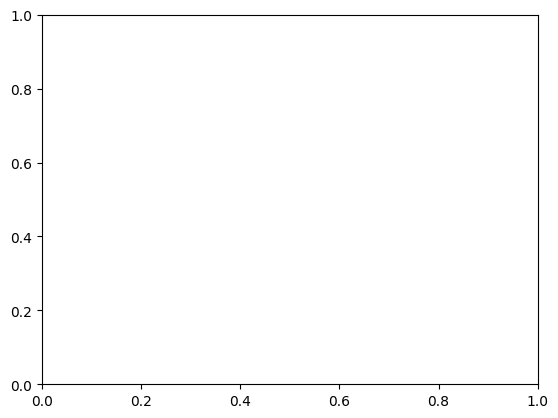

In [ ]:
_, ax = plt.subplots()
ax.hist(hist, bins=bins, density=True)
ax.set_xlabel(r"$\varphi$")
ax.set_ylabel(r"$P(\varphi)$")
#ax.set_yscale("log")

In [12]:
x=np.arange(-8,8,dtype=float)
print(x)
x1, x2 = jnp.split(x, 2, -1)
x1,x2
x1*flax.linen.sigmoid(x2)

[-8. -7. -6. -5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.]


Array([-4.        , -5.11741005, -5.28478247, -4.76287063, -3.92805516,
       -2.97992145, -1.99505475, -0.99908895], dtype=float64)

In [28]:
phase = (hist + np.pi) % (2*np.pi) - np.pi
bins=np.sort(list(set(phase)))
max(phase), min(phase), max(hist), min(hist)


(np.float64(1.5707963267948966),
 np.float64(-3.141592653589793),
 np.float64(15.707963267948966),
 np.float64(-15.707963267948966))

Text(0, 0.5, '$P(\\varphi)$')

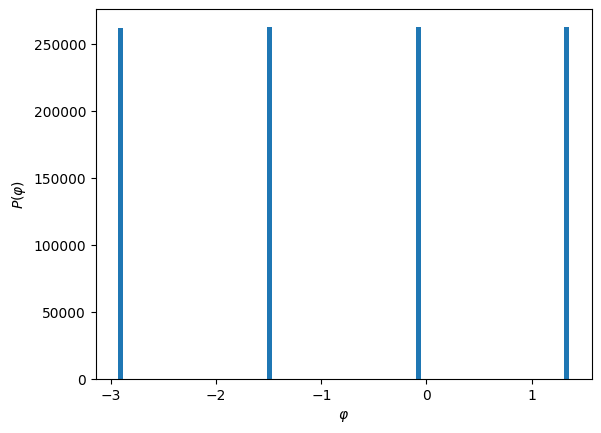

In [32]:

_, ax = plt.subplots()
ax.hist(phase,rwidth=0.1)
ax.set_xlabel(r"$\varphi$")
ax.set_ylabel(r"$P(\varphi)$")

In [31]:
set(phase),bins

({np.float64(-3.141592653589793),
  np.float64(-1.5707963267948966),
  np.float64(0.0),
  np.float64(1.5707963267948948),
  np.float64(1.5707963267948966)},
 array([-3.14159265, -1.57079633,  0.        ,  1.57079633,  1.57079633]))

In [1]:
%run SplitTraining_simulation_LRChain.py


Total samples: 1024


──────────────────────────────────── 🔧 CM: LRChain   🧠 NN_architecture: CvT3 ────────────────────────────────────

🧱 Size: 10x1

╭──────────────────────────────────────────────────── LRChain ────────────────────────────────────────────────────╮
│ fields= [-1.0, 0.0]  J= -6.0  alpha= 2.5                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── CvT3 ──────────────────────────────────────────────────────╮
│ n_CP_blocks= [2]              CTemb_channels= [32]  CP_channels= [32]  attn_heads= [4]   kernel= [3, 1]         │
│ final_architecture= (128,5,)  two_heads= True       symm_Z2= True      trivial_Z2= True  lattice_size= [10, 1]  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────

Running exact diagonalization...
Energy ED: -2.2745243669992172

Running with 0 sweeps...
Epochs: 500  Sweeps: 0


/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
2025-09-04 17:05:04.863122: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured t


Step 0:
Energy: -1.060418, Vscore: 3.420092

Step 1:
Energy: -1.065337, Vscore: 3.244179

Step 2:
Energy: -1.064869, Vscore: 2.856623

Step 3:
Energy: -1.056908, Vscore: 3.162813

Step 4:
Energy: -1.107870, Vscore: 2.634551

Step 5:
Energy: -1.147025, Vscore: 2.144423

Step 6:
Energy: -1.169658, Vscore: 2.200414

Step 7:
Energy: -1.186108, Vscore: 2.140708

Step 8:
Energy: -1.242878, Vscore: 1.808942

Step 9:
Energy: -1.286841, Vscore: 1.515528

Step 10:
Energy: -1.335778, Vscore: 1.309623

Step 11:
Energy: -1.451543, Vscore: 1.089146

Step 12:
Energy: -1.499543, Vscore: 0.902619

Step 13:
Energy: -1.523000, Vscore: 0.789947

Step 14:
Energy: -1.572589, Vscore: 0.675944

Step 15:
Energy: -1.639921, Vscore: 0.623260

Step 16:
Energy: -1.689085, Vscore: 0.574011

Step 17:
Energy: -1.678099, Vscore: 0.449585

Step 18:
Energy: -1.759935, Vscore: 0.426262

Step 19:
Energy: -1.803378, Vscore: 0.466322

Step 20:
Energy: -1.826017, Vscore: 0.397430

Step 21:
Energy: -1.872389, Vscore: 0.41940

ValueError: Unknown selector_mode: linear_combination

In [23]:
None*3


TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

In [99]:
import re
from NN_module.sim_utils import load_vstate
from netket.operator.spin import sigmaz
import netket.experimental as nkx

parent= "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/LRChain_CvT3"
parent_folder = parent if parent.endswith("/") else parent + "/"
files_list = []
for root, dirs, files in os.walk(parent_folder):

    for file in files:
        files_list.append(os.path.join(root, file))

files_list = [file for file in files_list if '.json' in file]
files_list_alpha = [file for file in files_list if '_alpha_2.5' in file]
J=[]
S=[]
m=[]
ms=[]
m2=[]
ms2=[]
var_m=[]
var_ms=[]

m_ED=[]
ms_ED=[]
m2_ED=[]
ms2_ED=[]
for file in files_list_alpha:
    # Load artifacts and simulation params
    with open(file,'r') as f:
        art = json.load(f)
    print(f"J: {art['coupling_model']['J']}")

    file_ED = art['_artifacts']['x_ED']
    x_ED = np.loadtxt(file_ED, dtype = complex)

    m_ED.append(M(x_ED).mean())
    ms_ED.append(Ms(x_ED).mean())
    m2_ED.append(M2(x_ED).mean())
    ms2_ED.append(Ms2(x_ED).mean())

    
    vstate=load_vstate(art)
    hi = vstate.hilbert
    N = vstate.hilbert.size

    renyi = nkx.observable.Renyi2EntanglementEntropy(
    hi, np.arange(0, N / 2 + 1, dtype=int)
    )   
    mags = sum([(-1) ** i * sigmaz(hi, i) / N for i in range(N)])
    magnet = sum([sigmaz(hi, i) / N for i in range(N)])

    J.append(art['coupling_model']['J'])
    S.append(np.real(vstate.expect(renyi).mean))
    m.append(np.real(vstate.expect(magnet).mean))
    ms.append(np.real(vstate.expect(mags).mean))
    m2.append(np.real(vstate.expect(magnet @ magnet).mean))
    ms2.append(np.real(vstate.expect(mags @ mags).mean))
    var_m.append(m2[-1]-m[-1]**2)
    var_ms.append(ms2[-1]-ms[-1]**2)



J: 3.5
J: -2.5
J: 4.5
J: 9.0
J: 0.0
J: 1.0
J: 3.0
J: -5.0
J: -4.0
J: 1.5
J: 2.0
J: 7.5
J: -5.5
J: 7.0
J: 5.5
J: -1.0
J: 6.5
J: 8.5
J: -4.5
J: 8.0
J: 5.0
J: 4.0
J: -6.0
J: -2.0
J: -1.5
J: 0.5
J: 2.5
J: 6.0
J: -3.5
J: -3.0
J: -0.5


In [100]:
J=np.array(J)
idx = np.argsort(J)
J = J[idx] 
S=np.array(S)[idx]
m=np.array(m)[idx]
ms=np.array(ms)[idx]
m2=np.array(m2)[idx]
ms2=np.array(ms2)[idx]
var_m=np.array(var_m)[idx]
var_ms=np.array(var_ms)[idx]

m_ED = np.array(m_ED)[idx]
ms_ED = np.array(ms_ED)[idx]
m2_ED = np.array(m2_ED)[idx]
ms2_ED = np.array(ms2_ED)[idx]


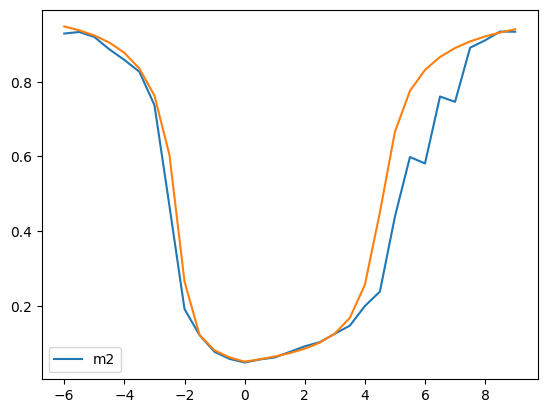

In [108]:

_, ax = plt.subplots()

# m
# x = np.where(J<0,m,ms)
# x_ED = np.where(J<0, m_ED, ms_ED)
# ax.plot(J, x, label = 'm')
# ax.plot(J, x_ED, label = 'm_ED')

# m2
x = np.where(J<0,m2,ms2)
x_ED = np.where(J<0, m2_ED, ms2_ED)
ax.plot(J, x, label = 'm2')
ax.plot(J, x_ED)

ax.legend()

In [98]:
def compute_spin_matrices(N):
    configs = np.arange(2**N)[:, None]            # todas las configuraciones
    bits = ((configs >> np.arange(N)) & 1)
    sigma_z = 0.5 - bits                               # valores ±1/2
    return sigma_z  # shape (2^N, N)

def M(state):
    """<M> magnetización media (uniforme, por sitio)"""
    N = int(np.log2(len(state)))
    sigma_z = 2 * compute_spin_matrices(N)
    probs = np.abs(state)**2
    M_exp = np.sum(probs[:, None] * sigma_z, axis=0).mean()   # promedio sobre sitios
    return M_exp

def M2(state):
    """<M^2> segundo momento de la magnetización uniforme"""
    N = int(np.log2(len(state)))
    sigma_z = 2 * compute_spin_matrices(N)
    probs = np.abs(state)**2

    # correladores S_i S_j
    corr = (probs[:, None, None] * (sigma_z[:, :, None] * sigma_z[:, None, :])).sum(axis=0)
    M2_exp = corr.sum() / (N**2)
    return M2_exp

def Ms(state):
    """<Ms> magnetización staggered media por sitio"""
    N = int(np.log2(len(state)))
    sigma_z = 2 * compute_spin_matrices(N)
    staggered = (-1)**np.arange(N)
    probs = np.abs(state)**2
    Ms_exp = np.sum(probs[:, None] * (sigma_z * staggered), axis=0).mean()
    return Ms_exp

def Ms2(state):
    """<Ms^2> segundo momento de la magnetización staggered"""
    N = int(np.log2(len(state)))
    sigma_z = 2 * compute_spin_matrices(N)
    probs = np.abs(state)**2
    staggered = (-1)**np.arange(N)

    sigma_z_stag = sigma_z * staggered  # shape (2^N, N)
    corr = (probs[:, None, None] * (sigma_z_stag[:, :, None] * sigma_z_stag[:, None, :])).sum(axis=0)
    Ms2_exp = corr.sum() / (N**2)
    return Ms2_exp



np.float64(1.5645893525102285e-15)

In [65]:
configs = np.arange(2**N)[:, None]  # columna
bits = ((configs >> np.arange(N)) & 1)
bits

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(1048576, 20))

In [ ]:
np.abs(np.vdot(vstate.to_array(),x_ED.squeeze()))

In [ ]:
import netket.experimental as nkx
hi = vstate.hilbert
N = vstate.hilbert.size
renyi = nkx.observable.Renyi2EntanglementEntropy(
    hi, np.arange(0, N / 2 + 1, dtype=int)
)
mags = sum([(-1) ** (i) * sigmaz(hi, i) /N for i in range(N)])
magnet = sum([sigmaz(hi, i) / N for i in range(N)])

In [ ]:
M_stats = vstate.expect(magnet)
M, M_var = float(M_stats.mean.real), float(M_stats.variance.real)
Ms = M_var + M**2

In [ ]:
M,M_var, Ms

In [ ]:
vstate.expect(magnet), vstate.expect(mags)

1.8508648061490227e-06


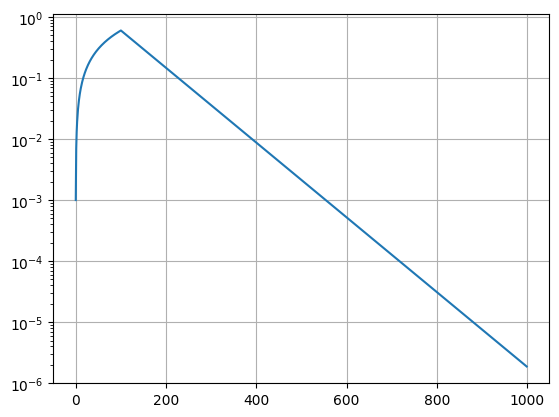

In [9]:
epochs=1000

fun=optax.warmup_exponential_decay_schedule(
            init_value=.001,
            peak_value=0.6,
            warmup_steps=100,
            transition_steps=1,
            decay_rate=0.986,
        )

print(fun(epochs))
x=np.arange(0,epochs)
y=fun(x)

_, ax = plt.subplots()
ax.plot(x, y)
ax.set_yscale('log')
ax.grid()

In [ ]:
a="/home/ihuarte/afwkcmlcn/afljnafu/Holaquetal.json"
os.path.basename(a)
os.path.dirname(a)

In [ ]:
oxa=OxalateJKGamma(
    [4,5], 
    [0.2, 9.0, 72.0],
    **{'bc': 'periodic', 'order': 'default_2'}
)
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(k=5, eigenstates=True)

In [ ]:
art_path='/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate_SplitTraining_ViT_CNN/Size_4x5/sweeps_0/Oxalate_SplitTraining_ViT_CNN_results_4x5_strength_0.2_theta_9.0_phi_72.0_channels_32_kernel_3x3_n_ffn_lay_1.json'

with open(art_path,'r') as f:
    artifact = json.load(f)

In [ ]:
x_ED = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/prueba/JKGamma/Split_oxalate_CNN/Oxalate_size_4x4/sweeps_20/Oxalate_xED_4x4_strength_0.2_theta_9.0_phi_72.0_ED.txt", dtype=complex)
x_vs = np.array(vstate.to_array())

In [ ]:



mod_vs, phase_vs, stats_vs = modphase(x_vs)
mod_ED, phase_ED, stats_ED = modphase(x_ED)



In [ ]:
a=(383,339)
print(f"|| {a} ||")

In [ ]:
import matplotlib.transforms as mtransforms
_,ax= plt.subplots(4,1, figsize=[15,10])

ax[0].set_title(r"$Modulus\;and\;Phase\qquad Oxalate\;size\;%d x %d \qquad a=%.1f\;\;\theta=%.1f \;\; \phi=%.1f$"%(4,4,0.2,9.0,72.0))
ax[0].set_xticks([])
ax[0].set_ylabel(r"$Modulus$")
ax[0].set_ylim(-0.01,max(max(mod_ED),max(mod_vs))*9/8)
ax[0].plot(mod_vs, alpha=0.6, color='r', label='vstate')
ax[0].plot(mod_ED, alpha=0.6, label='ED')
ax[0].legend()

ax[1].set_xticks([])
ax[1].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax[1].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
ax[1].set_ylabel(r"$Phase \;vstate$")
ax[1].set_ylim(-np.pi-0.1, np.pi+0.1)
ax[1].plot(phase_vs, alpha=0.25, ls='', marker='o', ms=0.9, color='r', label='vstate')
ax[1].legend(loc='upper right')

ax[2].set_xlabel(r"$C_i$")
ax[2].set_ylabel(r"$Phase \;ED$")
ax[2].set_ylim(-np.pi-0.1, np.pi+0.1)
ax[2].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax[2].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
ax[2].plot(phase_ED, alpha=0.25, ls='', marker='o', ms=0.9, label='ED')
ax[2].legend(loc='upper right')

ax[3].set_xlabel(r"$Phase\;(radians)$")
ax[3].set_ylabel(r"$Phase \;histogram$")
ax[3].hist(phase_ED, bins=1000, range=(-np.pi, np.pi), density=True, alpha=0.7, label='ED')
ax[3].hist(phase_vs, bins=1000, range=(-np.pi, np.pi), color='r', density=True, alpha=0.7, label='vstate')


transform = mtransforms.blended_transform_factory(ax[3].transData, ax[3].transAxes)
if stats_ED['peaks'] is not None:
    for peak in stats_ED['peaks']['values']:
        ax[3].text(peak-0.1, 0.9, r"%.2f"%peak, color='b', transform=transform, fontsize=8, alpha=0.7)

if stats_vs['peaks'] is not None:
    for peak in stats_vs['peaks']['values']:
        ax[3].text(peak-0.1, 0.9, r"%.2f"%peak, color='b', transform=transform, fontsize=8, alpha=0.7)
ax[3].legend()
plt.tight_layout()
plt.savefig(write_folder + files[j] + ".jpeg", dpi=600, bbox_inches="tight")

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(lr_schedule, marker='o',ls=None, label='Learning Rate Schedule')
ax.set_xlabel('Epochs')
ax.set_ylabel('Learning Rate')

In [ ]:
from VA_project.lattice.lattice import Chain,Square
from VA_project.model.cm import GeneralNeighborCoupling

size=[4,5]

fields=[(0., 'X'), (0.5, 'Z'), (0.8, 'Y')]
couplings=[(0.,'ZZ','NN'),(2.,'YY','NN2')]

chain= Square(*size,bc='periodic', order= 'default_1')
ZZYY= GeneralNeighborCoupling(chain, fields, couplings)
chain.plot_lattice(1)

In [ ]:
from NN_module.NN_utils import traslations_2D,traslations_2D_scan,traslations_2D_vmap

In [ ]:
a=jnp.arange(20)
size=[4,5]
token_size=[2,1]
sub_lat=[size[0]//token_size[0], size[1]//token_size[1]]
# a.reshape((sub_lat[1],token_size[1],sub_lat[0],token_size[0]),
#                   order='C').transpose((0, 2, 1, 3)).reshape(-1,token_size[0]*token_size[1]).squeeze()
#traslations_2D_scan(a,size).reshape(-1,*size)
traslations_2D(a,size, memory=False)#.reshape(-1,*size)



In [ ]:
import sys
from pathlib import Path
sys.path.append(str("/home/ihuarte/Escritorio/Ivan/ATMOS_VA/VA_project/src"))

from VA_project.model.model import OxalateJKGamma
from VA_project.engine.runners import Runner
from NN_module.sim_utils import (
    load_vstate
)
files=[
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_128_heads_2_blocks_2_ffn_lay_2.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_8_blocks_2_ffn_lay_4.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_2_blocks_2_ffn_lay_4.json"
]

size=[4,4]
strength=0.2
theta=54.
phi=0.
kwargs_lattice={
    'bc':'periodic',
    'order':'default_2'
}

oxa=OxalateJKGamma(
            size, 
            [strength, theta, phi],
            **kwargs_lattice
        )
H = Runner(oxa.cm).build_hamiltonian()
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(eigenstates=True, k=150)
idx=np.argsort(E_ED)
E_ED=E_ED[idx]
x_ED=x_ED.T[idx,:]

In [ ]:
i=2
path_artifact= files[i]

with open(path_artifact,'r') as f:
    artifact = json.load(f)

vstate=load_vstate(artifact).to_array()
vstate=np.array(vstate, dtype=np.complex128)


In [ ]:
c=np.sum(x_ED.conjugate()*vstate, axis=1)
P=np.abs(c)**2
sum(P)

In [ ]:
E_best=artifact['results']['E_best']
e=-np.inf; idx=0
while e<E_best:
    e=E_ED[idx]
    idx+=1

idx, E_ED[idx],E_ED[idx-1]

In [ ]:
P_sum=sum(P)

_,ax=plt.subplots()
ax.set_title(f"Projections #{i}")
ax.set_xlabel("Eigenstates")
ax.set_ylabel("Probability")
ax.bar(range(len(P)), P, label=r"$\Sigma_i\; P_i$")
ax.vlines(idx, 0,max(P), color='r', ls='--', label=r"$\sim E_{sim}$")
ax.legend(fontsize=8)
ax.text(0.5, 0.8, r"$\Sigma_i\; P_i = %.4f$"%P_sum+"\n"+r"$E_1=%.3f$"%E_ED[0]+"\n"+r"$E_{150}=%.3f$"%(E_ED[-1])+"\n"+r"$E_{sim}=%.3f$"%E_best, transform=ax.transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.4))
#ax.set_yscale('log')

In [ ]:
a=False
b=True
not a and b

# Learning Rate Scheduler

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from NN_module.NN_utils import scheduler_initializer

In [ ]:

schedule={
    'epochs': 500,
    'cos_exp_scheduler':{
        "lr0":0.6,
        "decay_exp":1.,
        "cosine_cycles":2.,
        "n":0.1,
        "lr_min": 0.01
    }
}

lr_sch=scheduler_initializer('cos_exp_scheduler', schedule)


# recta = lambda x: (lr_min-n)/epochs*x+n
# y_recta=recta(jnp.arange(0,epochs))

y=lr_sch(jnp.arange(0,schedule['epochs']))

_,ax= plt.subplots(1,1,figsize=(10,5))
ax.plot(y, label="exp decay")
#ax.plot(np.arange(epochs),y_recta, ls= '--', color='r')
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
#ax.set_ylim(0, 1.05)
ax.legend()
ax.grid()

In [ ]:
21388438632/(1024)**3

In [ ]:
import jax.numpy as jnp
import jax
a= jnp.ones((4,4), dtype=complex)/10
b= jnp.ones((4,4) ,dtype=complex)


stack=jnp.array([a,b]).transpose(1,0,2)
z2_sym=jax.nn.logsumexp(
    stack,
    b=jnp.array([1., -1.])[None,:,None],
    axis=1
)
z2_2d_symm=jax.nn.logsumexp(
    z2_sym,
    axis=0
)

In [ ]:
from flax.serialization import to_bytes, from_bytes
import msgpack
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/Oxalate_vstate_params_4x4_strength_0.2_theta_90.0_phi_115.2_b_2x1_Demb_64_heads_4_blocks_2_ffn_lay_4.msgpack"

In [ ]:
with open(file, "rb") as f:
    bytes_data = f.read()

# Decodifica con msgpack sin un schema de Flax
unpacked = msgpack.unpackb(bytes_data, raw=False)

import pprint
pprint.pprint(unpacked)


In [ ]:
_, ax= plt.subplots()
x=np.arange(50,300)
ax.set_ylim(0,0.1)
ax.set_xlim(0,300)
ax.plot(x,0.05*0.987**(x-50))

In [ ]:
import numpy as np
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_xED_4x5_strength_0.2_theta_0_phi_0.txt"
x_ED= np.loadtxt(file, dtype=complex)
x_ED

In [ ]:
jnp.angle(x_ED)

In [ ]:
from NN_module.sim_utils import load_vstate
import json
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_results_4x5_strength_0.2_theta_0_phi_0_XZ_-1.0_0.001_J_1.5_alpha_2.5_b_2x1_Demb_32_heads_2_blocks_2_ffn_lay_2.json"

In [ ]:
with open(file,'rb') as f:
    conf=json.load(f)

vstate=load_vstate(conf)